## Cell 1 — Cài đặt thư viện

In [1]:
# Cập nhật torchao và cài đặt các thư viện cần thiết
!pip install -q "torchao>=0.16.0"
!pip install -q transformers accelerate peft pillow tqdm deep_translator
!pip install -q evaluate bert_score
!pip install -q "pillow<12.0"
print("Cài đặt thư viện hoàn tất!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.6 MB/s eta 0:00:00
Cài đặt thư viện hoàn tất!


## Cell 2 — Cấu hình toàn cục & Login HuggingFace

In [13]:
import os, json, time, random, math
from pathlib import Path
from copy import deepcopy

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

from transformers import BlipProcessor, BlipForQuestionAnswering, get_cosine_schedule_with_warmup
from peft import PeftModel


# CẤU HÌNH
SFT_REPO        = "lpv30/DL-CK"
DPO_REPO        = "lpv30/DL-CK-DPO"
BASE_MODEL_NAME = "Salesforce/blip-vqa-base"

# Paths dữ liệu
VAL_JSON   = "data/data/val_en.json"
TEST_JSON  = "data/data/test_en.json"
DATA_ROOT  = "/content/data"

# DPO Hyperparameters
BETA              = 0.4
DPO_EPOCHS        = 3
BATCH_SIZE        = 2
GRAD_ACCUM        = 4
LR                = 5e-6
MAX_QUESTION_LEN  = 64
MAX_ANSWER_LEN    = 32
MIN_BERTSCORE     = 0.70
NUM_PAIRS         = 300

OUTPUT_DIR = "/content/checkpoints/blip_dpo"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cuda


## Cell 3 — Login HuggingFace & giải nén dữ liệu

In [3]:
# Đăng nhập trực tiếp bằng Token để tránh lỗi widget
from huggingface_hub import login
import getpass

print("Vui lòng nhập Hugging Face Access Token (Cần chọn quyền WRITE):")
token = getpass.getpass()

if token:
    login(token=token)
    print("Đăng nhập thành công!")
else:
    print("Bạn chưa nhập token. Lấy token tại: https://huggingface.co/settings/tokens")

Vui lòng nhập Hugging Face Access Token (Cần chọn quyền WRITE):
··········
Đăng nhập thành công!


In [4]:
# Giải nén data (nếu chưa có)
import os
if not os.path.exists("data"):
    !unzip -q /content/data.zip -d /content/data
    print("Đã giải nén data.zip")
else:
    print("Data đã tồn tại, bỏ qua giải nén.")

data/images/bánh_cuốn/:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/),
         continuing with "central" filename version
data/images/bánh_cuốn/000001.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/000001.jpg),
         continuing with "central" filename version
data/images/bánh_cuốn/000002.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/000002.jpg),
         continuing with "central" filename version
data/images/bánh_cuốn/000003.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/000003.jpg),
         continuing with "central" filename version
data/images/bánh_cuốn/000004.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/000004.jpg),
         continuing with "central" filename version
data/images/bánh_cuốn/000005.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/000005.jpg),
         continuing with "central" filename version
data/images/bánh_cuốn/000006.jpg:  mismatching "local" filename (data/images/b├бnh_cuс╗Сn/

## Cell 4 — Translator (VI ↔ EN)

In [5]:
from deep_translator import GoogleTranslator

class ViEnTranslator:
    """Wrapper GoogleTranslator miễn phí, không cần API key."""
    def __init__(self):
        self.vi2en = GoogleTranslator(source="vi", target="en")
        self.en2vi = GoogleTranslator(source="en", target="vi")

    def to_english(self, text: str) -> str:
        try:
            return self.vi2en.translate(text) or text
        except Exception:
            return text

    def to_vietnamese(self, text: str) -> str:
        try:
            return self.en2vi.translate(text) or text
        except Exception:
            return text

translator = ViEnTranslator()
print("ViEnTranslator sẵn sàng.")

ViEnTranslator sẵn sàng.


## Cell 5 — Load SFT Model từ HuggingFace

In [6]:
from peft import PeftModel
from peft.tuners.lora import LoraLayer

print(f"Loading SFT model từ: {SFT_REPO}")

processor = BlipProcessor.from_pretrained(SFT_REPO)

BASE_MODEL_NAME = "Salesforce/blip-vqa-base"
processor = BlipProcessor.from_pretrained(BASE_MODEL_NAME)
base_model = BlipForQuestionAnswering.from_pretrained(BASE_MODEL_NAME).to(DEVICE)
base_model.eval()

# SFT model → dùng làm dpo_model (sẽ train)
base_model = BlipForQuestionAnswering.from_pretrained(BASE_MODEL_NAME)
sft_model  = PeftModel.from_pretrained(base_model, SFT_REPO)
sft_model  = sft_model.to(DEVICE)

# Unfreeze tất cả LoRA params sau khi load
for name, param in sft_model.named_parameters():
    if "lora_" in name:          # chỉ unfreeze LoRA weights
        param.requires_grad = True
    else:
        param.requires_grad = False  # base weights vẫn frozen

dpo_model = sft_model
dpo_model.train()

# ref_model → frozen hoàn toàn
ref_base  = BlipForQuestionAnswering.from_pretrained(BASE_MODEL_NAME)
ref_model = PeftModel.from_pretrained(ref_base, SFT_REPO)
ref_model = ref_model.merge_and_unload()   # merge LoRA vào base
ref_model = ref_model.to(DEVICE)
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad = False

print("Load model thành công!")
total_params     = sum(p.numel() for p in dpo_model.parameters())
trainable_params = sum(p.numel() for p in dpo_model.parameters() if p.requires_grad)
print(f"Tổng params       : {total_params:,}")
print(f"Trainable params  : {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

Loading SFT model từ: lpv30/DL-CK


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/544 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/509 [00:00<?, ?B/s]

...

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/30.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Load model thành công!
Tổng params       : 392,364,860
Trainable params  : 7,692,288 (1.96%)


## Cell 6 — Tạo Preference Data (Chosen / Rejected)



In [7]:
from evaluate import load as eval_load

bertscore_metric = eval_load("bertscore")

def generate_answer(model, proc, image_path, question_en, device, max_new_tokens=50):
    """Sinh câu trả lời tiếng Anh từ model."""
    try:
        image = Image.open(image_path).convert("RGB")
    except Exception:
        return None
    inputs = proc(images=image, text=question_en, return_tensors="pt").to(device)
    with torch.no_grad():
        ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
        )
    return proc.decode(ids[0], skip_special_tokens=True)


def build_preference_data(val_json, data_root, model, proc, device,
                              num_pairs=300, min_bertscore=0.90,
                              cache_path="pref_data.json"):
    if os.path.exists(cache_path):
        print(f"Cache tồn tại: {cache_path}")
        with open(cache_path, encoding="utf-8") as f:
            return json.load(f)

    with open(val_json, encoding="utf-8") as f:
        samples = json.load(f)

    def normalize(text):
        return text.strip().lower().rstrip(".")

    # Bước 1: Inference
    all_preds, all_refs, all_meta = [], [], []
    model.eval()
    for s in tqdm(samples, desc="Inference"):
        img_path = os.path.join(data_root, s["image_path"].replace("\\", "/"))
        pred = generate_answer(model, proc, img_path, s["question_en"], device)
        if not pred or pred.strip() == "":
            continue
        all_preds.append(pred)
        all_refs.append(s["answer_en"])
        all_meta.append(s)

    # Bước 2: BERTScore
    print("Tính BERTScore...")
    bs = bertscore_metric.compute(
        predictions=all_preds, references=all_refs,
        lang="en", device=str(device)
    )
    f1_scores = bs["f1"]

    import statistics
    print(f"BERTScore - Min:{min(f1_scores):.3f} | Mean:{statistics.mean(f1_scores):.3f} | Max:{max(f1_scores):.3f}")

    # Bước 3: Tạo pairs
    from collections import defaultdict
    pairs = []
    by_type = defaultdict(list)
    for i, m in enumerate(all_meta):
        by_type[m["type"]].append((i, m))

    for i, (f1, m, pred) in enumerate(zip(f1_scores, all_meta, all_preds)):
        gt_norm   = normalize(m["answer_en"])
        pred_norm = normalize(pred)
        is_wrong  = (gt_norm != pred_norm)          # Exact match sai
        is_low_bs = (f1 < min_bertscore)            # BERTScore thấp

        # Chiến lược A: prediction sai (exact match) → dù BERTScore cao vẫn dùng
        if is_wrong:
            pairs.append({
                "image_path":  m["image_path"],
                "label":       m["label"],
                "type":        m["type"],
                "question_vi": m["question"],
                "question_en": m["question_en"],
                "answer_vi":   m["answer"],
                "chosen":      m["answer_en"],
                "rejected":    pred,
                "bertscore":   round(f1, 4),
                "strategy":    "exact_mismatch",
            })

        # Chiến lược B: hard negative từ sample khác (luôn tạo thêm để đủ số lượng)
        same_type = [(j, n) for j, n in by_type[m["type"]] if j != i]
        if same_type:
            j, neg = random.choice(same_type)
            if normalize(neg["answer_en"]) != gt_norm:
                pairs.append({
                    "image_path":  m["image_path"],
                    "label":       m["label"],
                    "type":        m["type"],
                    "question_vi": m["question"],
                    "question_en": m["question_en"],
                    "answer_vi":   m["answer"],
                    "chosen":      m["answer_en"],
                    "rejected":    neg["answer_en"],  # đáp án của ảnh khác
                    "bertscore":   round(f1, 4),
                    "strategy":    "hard_negative",
                })

    # Bước 4: Cân bằng theo type
    by_type_pairs = defaultdict(list)
    for p in pairs:
        by_type_pairs[p["type"]].append(p)

    per_type = num_pairs // max(len(by_type_pairs), 1)
    balanced = []
    for t, ps in by_type_pairs.items():
        # Ưu tiên exact_mismatch trước, hard_negative bổ sung sau
        priority = [p for p in ps if p["strategy"] == "exact_mismatch"]
        fallback = [p for p in ps if p["strategy"] == "hard_negative"]
        random.shuffle(priority)
        random.shuffle(fallback)
        chosen = (priority + fallback)[:per_type]
        balanced.extend(chosen)

    random.shuffle(balanced)

    strategies = defaultdict(int)
    for p in balanced:
        strategies[p["strategy"]] += 1
    print(f"{len(balanced)} pairs")
    print(f"Chiến lược: {dict(strategies)}")
    print(f"Phân bổ type: { {t: len([p for p in balanced if p['type']==t]) for t in by_type_pairs} }")

    with open(cache_path, "w", encoding="utf-8") as f:
        json.dump(balanced, f, ensure_ascii=False, indent=2)

    return balanced
if os.path.exists("/content/pref_data.json"):
    os.remove("/content/pref_data.json")

preference_data = build_preference_data(
    VAL_JSON, DATA_ROOT, base_model, processor, DEVICE,
    num_pairs=NUM_PAIRS, min_bertscore=MIN_BERTSCORE,
    cache_path="/content/pref_data.json"
)

Inference: 100%|██████████| 300/300 [01:23<00:00,  3.59it/s]


Tính BERTScore...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore - Min:0.825 | Mean:0.913 | Max:0.989
300 pairs
Chiến lược: {'exact_mismatch': 258, 'hard_negative': 42}
Phân bổ type: {'recognition': 60, 'color': 60, 'counting': 60, 'yes_no': 60, 'ingredient': 60}


## Cell 7 — DPO Dataset

Mỗi sample trong DPO Dataset trả về:
- `pixel_values`, `input_ids`, `attention_mask` (ảnh + câu hỏi)
- `chosen_ids`, `chosen_mask`, `chosen_labels`
- `rejected_ids`, `rejected_mask`, `rejected_labels`

In [8]:
class DPODataset(Dataset):
    def __init__(self, pairs, data_root, processor):
        self.pairs     = pairs
        self.data_root = data_root
        self.proc      = processor

    def __len__(self):
        return len(self.pairs)

    def _encode_answer(self, text):
        enc = self.proc.tokenizer(
            text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=MAX_ANSWER_LEN,
        )
        ids    = enc.input_ids.squeeze(0)
        mask   = enc.attention_mask.squeeze(0)
        labels = ids.clone()
        labels[labels == self.proc.tokenizer.pad_token_id] = -100
        return ids, mask, labels

    def __getitem__(self, idx):
        pair     = self.pairs[idx]
        img_path = os.path.join(self.data_root, pair["image_path"].replace("\\", "/"))
        image    = Image.open(img_path).convert("RGB")

        enc = self.proc(
            images=image,
            text=pair["question_en"],
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=MAX_QUESTION_LEN,
        )

        chosen_ids,   chosen_mask,   chosen_labels   = self._encode_answer(pair["chosen"])
        rejected_ids, rejected_mask, rejected_labels = self._encode_answer(pair["rejected"])

        return {
            "pixel_values":    enc.pixel_values.squeeze(0),
            "input_ids":       enc.input_ids.squeeze(0),
            "attention_mask":  enc.attention_mask.squeeze(0),
            "chosen_ids":      chosen_ids,
            "chosen_mask":     chosen_mask,
            "chosen_labels":   chosen_labels,
            "rejected_ids":    rejected_ids,
            "rejected_mask":   rejected_mask,
            "rejected_labels": rejected_labels,
        }


def dpo_collate(batch):
    keys = batch[0].keys()
    return {k: torch.stack([b[k] for b in batch]) for k in keys}


# Train/val split từ preference data (90/10)
random.shuffle(preference_data)
n_val   = max(int(len(preference_data) * 0.1), 10)
pref_train = preference_data[n_val:]
pref_val   = preference_data[:n_val]

dpo_train_ds = DPODataset(pref_train, DATA_ROOT, processor)
dpo_val_ds   = DPODataset(pref_val,   DATA_ROOT, processor)

dpo_train_loader = DataLoader(dpo_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               collate_fn=dpo_collate, num_workers=2, pin_memory=True)
dpo_val_loader   = DataLoader(dpo_val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                               collate_fn=dpo_collate, num_workers=2, pin_memory=True)

print(f"DPO train: {len(dpo_train_ds)} pairs | val: {len(dpo_val_ds)} pairs")
print(f"Batch size: {BATCH_SIZE} | Grad accum: {GRAD_ACCUM} | Effective batch: {BATCH_SIZE*GRAD_ACCUM}")

DPO train: 270 pairs | val: 30 pairs
Batch size: 2 | Grad accum: 4 | Effective batch: 8


## Cell 8 — DPO Loss Function

**DPO Loss** (Direct Preference Optimization — Rafailov et al. 2023):

$$\mathcal{L}_{DPO} = -\log \sigma \left( \beta \cdot \left[ \log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \log \frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)} \right] \right)$$

Trong đó:
- $y_w$ = chosen (câu trả lời đúng / BERTScore cao)
- $y_l$ = rejected (câu trả lời sai / BERTScore thấp)
- $\beta$ = hệ số KL penalty (0.1)
- $\pi_{ref}$ = SFT model (frozen reference)
- $\pi_\theta$ = DPO model (được train)

In [10]:
def compute_logprobs(model, pixel_values, input_ids, attention_mask, decoder_input_ids, decoder_attention_mask, labels=None):
    """
    Tính tổng log-probabilities cho các câu trả lời dựa trên logits của mô hình BLIP.
    """
    # 1. TRÍCH XUẤT MODEL LÕI
    if hasattr(model, "base_model") and hasattr(model.base_model, "model") and hasattr(model.base_model.model, "vision_model"):
        # Trường hợp dpo_model đang bị bọc bởi PeftModel
        core_model = model.base_model.model
    else:
        # Trường hợp ref_model đã được merge_and_unload()
        core_model = model

    # 2. Chạy qua Vision Encoder (Trích xuất đặc trưng ảnh)
    vision_outputs = core_model.vision_model(pixel_values=pixel_values)
    image_embeds = vision_outputs.last_hidden_state

    # Tạo attention_mask riêng cho ảnh (BLIP yêu cầu)
    image_attention_mask = torch.ones(image_embeds.size()[:-1], dtype=torch.long, device=image_embeds.device)

    # 3. Chạy qua Text Encoder (Kết hợp đặc trưng ảnh và câu hỏi)
    question_embeds = core_model.text_encoder(
        input_ids=input_ids,
        attention_mask=attention_mask,
        encoder_hidden_states=image_embeds,
        encoder_attention_mask=image_attention_mask,
        return_dict=True,
    ).last_hidden_state

    # 4. Chạy qua Text Decoder (Sinh câu trả lời & ép mô hình phải nhả LOGITS ra)
    decoder_outputs = core_model.text_decoder(
        input_ids=decoder_input_ids,
        attention_mask=decoder_attention_mask,
        encoder_hidden_states=question_embeds,
        encoder_attention_mask=attention_mask,
        return_dict=True,
    )

    logits = decoder_outputs.logits  # Shape: (Batch_size, Seq_length, Vocab_size)

    # 5. TÍNH TOÁN LOG PROBABILITIES

    # Căn chỉnh (shift) logits và labels vì đây là bài toán dự đoán từ tiếp theo
    shift_logits = logits[:, :-1, :].contiguous()          # (B, T-1, V)
    shift_labels = decoder_input_ids[:, 1:].contiguous()   # (B, T-1)
    shift_mask = decoder_attention_mask[:, 1:].contiguous()# (B, T-1)

    # Dùng CrossEntropyLoss (không lấy trung bình) để tính xác suất cho từng token
    loss_fct = torch.nn.CrossEntropyLoss(reduction='none')

    # Flatten ra để tính loss: shape (-1, V) và (-1)
    token_logprobs = -loss_fct(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1)
    )

    # Reshape lại về dạng ban đầu: (Batch_size, Seq_length - 1)
    token_logprobs = token_logprobs.view(shift_labels.size(0), shift_labels.size(1))

    # Nhân với mask để bỏ qua (không cộng) những token padding (giá trị 0)
    token_logprobs = token_logprobs * shift_mask

    # Tính tổng logprobs của cả câu
    sum_logprobs = token_logprobs.sum(dim=1)

    return sum_logprobs


def dpo_loss(policy_model, ref_model_frozen, batch, beta, device):
    """
    Tính DPO loss cho một batch.
    Returns: loss (scalar), reward_margin (scalar cho monitoring)
    """
    pv   = batch["pixel_values"].to(device)
    iids = batch["input_ids"].to(device)
    amsk = batch["attention_mask"].to(device)

    c_ids  = batch["chosen_ids"].to(device)
    c_msk  = batch["chosen_mask"].to(device)
    c_lbl  = batch["chosen_labels"].to(device)

    r_ids  = batch["rejected_ids"].to(device)
    r_msk  = batch["rejected_mask"].to(device)
    r_lbl  = batch["rejected_labels"].to(device)

    # Log-probs từ policy model (cần gradient)
    with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
        logp_chosen_policy   = compute_logprobs(policy_model, pv, iids, amsk, c_ids, c_msk, c_lbl)
        logp_rejected_policy = compute_logprobs(policy_model, pv, iids, amsk, r_ids, r_msk, r_lbl)

    # Log-probs từ reference model (không cần gradient)
    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            logp_chosen_ref   = compute_logprobs(ref_model_frozen, pv, iids, amsk, c_ids, c_msk, c_lbl)
            logp_rejected_ref = compute_logprobs(ref_model_frozen, pv, iids, amsk, r_ids, r_msk, r_lbl)

    # DPO reward margin
    log_ratio_chosen   = logp_chosen_policy   - logp_chosen_ref
    log_ratio_rejected = logp_rejected_policy - logp_rejected_ref
    reward_margin = (log_ratio_chosen - log_ratio_rejected).mean().item()

    # DPO loss = -log σ(β * (log_ratio_chosen - log_ratio_rejected))
    loss = -F.logsigmoid(beta * (log_ratio_chosen - log_ratio_rejected)).mean()
    return loss, reward_margin


print("DPO loss function định nghĩa xong.")

DPO loss function định nghĩa xong.


## Cell 9 — Optimizer & Scheduler

In [11]:
from torch.optim import AdamW

optimizer = AdamW(
    [p for p in dpo_model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=0.01,
)

total_steps   = math.ceil(len(dpo_train_loader) / GRAD_ACCUM) * DPO_EPOCHS
warmup_steps  = max(int(total_steps * 0.1), 10)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

scaler = torch.amp.GradScaler()

print(f"Total DPO steps  : {total_steps}")
print(f"Warmup steps     : {warmup_steps}")
print(f"LR               : {LR}")

Total DPO steps  : 340
Warmup steps     : 34
LR               : 5e-05


## Cell 10 — Vòng lặp DPO Training

In [ ]:
dpo_history = {"train_loss": [], "val_loss": [], "reward_margin": []}
best_val_loss = math.inf

print(f"{'='*60}")
print(f"Bắt đầu DPO Training — {DPO_EPOCHS} epoch(s)")
print(f"BETA = {BETA} | LR = {LR} | Effective batch = {BATCH_SIZE * GRAD_ACCUM}")
print(f"{'='*60}\n")

for epoch in range(1, DPO_EPOCHS + 1):
    print(f"\n{'─'*55}")
    print(f"Epoch {epoch}/{DPO_EPOCHS}")
    print(f"{'─'*55}")

    # ── Training ──
    dpo_model.train()
    torch.cuda.empty_cache()
    train_loss_total = 0.0
    reward_total     = 0.0
    n_steps = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(dpo_train_loader, desc=f"  Train")):
        loss, reward = dpo_loss(dpo_model, ref_model, batch, BETA, DEVICE)
        loss_scaled  = loss / GRAD_ACCUM

        scaler.scale(loss_scaled).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in dpo_model.parameters() if p.requires_grad], 1.0
            )
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        train_loss_total += loss.item()
        reward_total     += reward
        n_steps          += 1

    avg_train_loss = train_loss_total / n_steps
    avg_reward     = reward_total / n_steps

    # ── Validation ──
    dpo_model.eval()
    val_loss_total = 0.0
    n_val_steps    = 0

    with torch.no_grad():
        for batch in tqdm(dpo_val_loader, desc=f"  Val  "):
            loss, _ = dpo_loss(dpo_model, ref_model, batch, BETA, DEVICE)
            val_loss_total += loss.item()
            n_val_steps    += 1

    avg_val_loss = val_loss_total / max(n_val_steps, 1)

    dpo_history["train_loss"].append(avg_train_loss)
    dpo_history["val_loss"].append(avg_val_loss)
    dpo_history["reward_margin"].append(avg_reward)

    print(f"\nEpoch {epoch:2d} | train_loss={avg_train_loss:.4f} | "
          f"val_loss={avg_val_loss:.4f} | reward_margin={avg_reward:.4f}")

    # Lưu best checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        dpo_model.save_pretrained(OUTPUT_DIR)
        processor.save_pretrained(OUTPUT_DIR)
        print(f"Saved best DPO checkpoint (val_loss={avg_val_loss:.4f})")


print(f"DPO Training hoàn tất! Best val_loss = {best_val_loss:.4f}")

Bắt đầu DPO Training — 3 epoch(s)
BETA = 0.4 | LR = 5e-06 | Effective batch = 8


───────────────────────────────────────────────────────
Epoch 1/3
───────────────────────────────────────────────────────


  Val  : 100%|██████████| 15/15 [00:05<00:00,  2.66it/s]



  ✅ Epoch  1 | train_loss=0.6068 | val_loss=0.5321 | reward_margin=0.5910
  💾 Saved best DPO checkpoint (val_loss=0.5321)

───────────────────────────────────────────────────────
Epoch 2/3
───────────────────────────────────────────────────────


  Val  : 100%|██████████| 15/15 [00:06<00:00,  2.37it/s]



  ✅ Epoch  2 | train_loss=0.3096 | val_loss=0.4463 | reward_margin=3.4622
  💾 Saved best DPO checkpoint (val_loss=0.4463)

───────────────────────────────────────────────────────
Epoch 3/3
───────────────────────────────────────────────────────


  Val  : 100%|██████████| 15/15 [00:05<00:00,  2.57it/s]



  ✅ Epoch  3 | train_loss=0.1564 | val_loss=0.3732 | reward_margin=6.0919
  💾 Saved best DPO checkpoint (val_loss=0.3732)

DPO Training hoàn tất! Best val_loss = 0.3732


## Cell 11 — Vẽ biểu đồ DPO Training

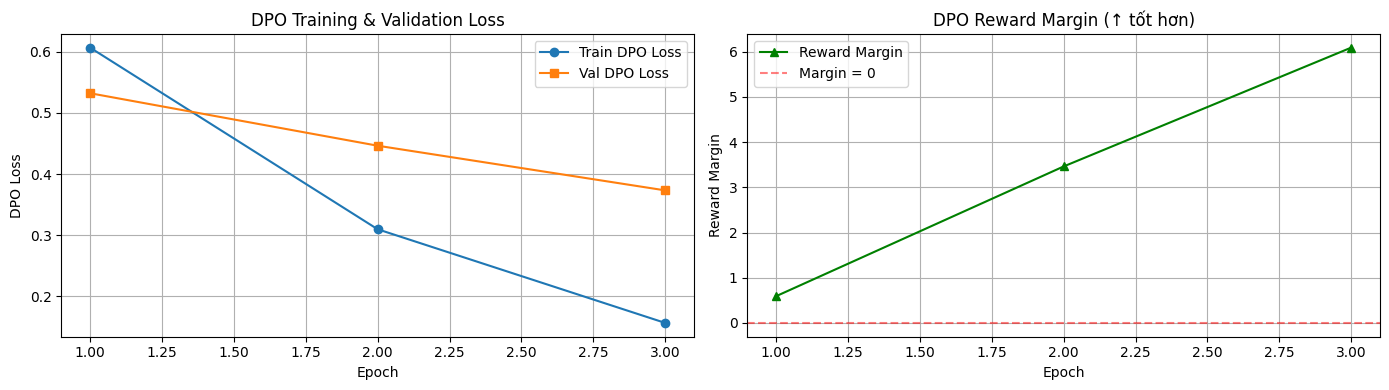

Đã lưu: dpo_training_curves.png

📊 Reward Margin > 0 nghĩa là model đã học ưu tiên chosen hơn rejected ✅


In [15]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(dpo_history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot Loss
axes[0].plot(epochs_range, dpo_history["train_loss"], marker="o", label="Train DPO Loss")
axes[0].plot(epochs_range, dpo_history["val_loss"],   marker="s", label="Val DPO Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("DPO Loss")
axes[0].set_title("DPO Training & Validation Loss")
axes[0].legend()
axes[0].grid(True)

# Plot Reward Margin
axes[1].plot(epochs_range, dpo_history["reward_margin"], marker="^", color="green", label="Reward Margin")
axes[1].axhline(y=0, color="red", linestyle="--", alpha=0.5, label="Margin = 0")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Reward Margin")
axes[1].set_title("DPO Reward Margin (↑ tốt hơn)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("dpo_training_curves.png", dpi=150)
plt.show()
print("Đã lưu: dpo_training_curves.png")

# Giải thích reward margin
print("\nReward Margin > 0 nghĩa là model đã học ưu tiên chosen hơn rejected")

## Cell 12 — Push DPO Model lên HuggingFace Hub

In [16]:
print(f"Đang đẩy DPO model lên: {DPO_REPO}")

try:
    # Load lại best checkpoint
    best_base = BlipForQuestionAnswering.from_pretrained(BASE_MODEL_NAME)
    best_dpo  = PeftModel.from_pretrained(best_base, OUTPUT_DIR)

    best_dpo.push_to_hub(DPO_REPO, commit_message="DPO fine-tuned from SFT (BERTScore reward)")
    processor.push_to_hub(DPO_REPO)
    print(f"Đã đẩy DPO model lên: https://huggingface.co/{DPO_REPO}")
except Exception as e:
    print(f"Lỗi push: {e}")
    print("Kiểm tra: (1) đã notebook_login chưa, (2) repo đã tạo chưa, (3) token có quyền WRITE không")

Đang đẩy DPO model lên: lpv30/DL-CK-DPO


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   2%|1         |  557kB / 30.8MB            

✅ Đã đẩy DPO model lên: https://huggingface.co/lpv30/DL-CK-DPO
